In [51]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, roc_curve, roc_auc_score, silhouette_score
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline


In [52]:
# Install kagglehub if not already installed
!pip install kagglehub

In [53]:
import kagglehub
import os

# Download the dataset
# This will return the path to the downloaded dataset, which is usually a directory
dataset_dir_path = kagglehub.dataset_download("liujiaqi/hr-comma-sepcsv")

# Construct the full path to the HR_comma_sep.csv file within the downloaded directory
# Assuming the CSV file is directly inside the downloaded directory
actual_csv_path = os.path.join(dataset_dir_path, 'HR_comma_sep.csv')

print(f"Dataset downloaded to: {dataset_dir_path}")
print(f"Actual CSV file path: {actual_csv_path}")

# Now, we will update the 'file_path' variable in the original data loading cell
# (uDW9Dr7ui_V-) to use this 'actual_csv_path'.

Using Colab cache for faster access to the 'hr-comma-sepcsv' dataset.
Dataset downloaded to: /kaggle/input/hr-comma-sepcsv
Actual CSV file path: /kaggle/input/hr-comma-sepcsv/HR_comma_sep.csv


In [54]:
import os

# Reading the Dataset
file_path = actual_csv_path # Use the path from the kagglehub download

if not os.path.exists(file_path):
    print(f"Error: The file '{file_path}' was not found.")
    print("This might indicate an issue with the kagglehub download or path construction.")
else:
    df = pd.read_csv(file_path)
    df.rename(columns={'sales': 'department'}, inplace=True)
    df_raw = df.copy()  # Keep original categorical values for leakage-safe modeling
    print(f"Successfully loaded data from '{file_path}'. First 5 rows:")
    display(df.head())

Successfully loaded data from '/kaggle/input/hr-comma-sepcsv/HR_comma_sep.csv'. First 5 rows:


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


### Dataset preparation
The `department` column is renamed from `sales`. A separate `df_raw` copy is retained so categorical features remain intact for the modeling pipeline.

In [55]:
#Checking if there are missing Values or not
df.isnull().sum()

,0
satisfaction_level,0
last_evaluation,0
number_project,0
average_montly_hours,0
time_spend_company,0
Work_accident,0
left,0
promotion_last_5years,0
department,0
salary,0


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [57]:
#Getting count of unique variables in categorical features
cat_col = ['department', 'salary']
for col in cat_col:
    print(f"{col}, no. of unique columns: {df[col].nunique()}")

department, no. of unique columns: 10
salary, no. of unique columns: 3


In [58]:
for col in cat_col:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

In [59]:
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,7,1
1,0.80,0.86,5,262,6,0,1,0,7,2
2,0.11,0.88,7,272,4,0,1,0,7,2
3,0.72,0.87,5,223,5,0,1,0,7,1
4,0.37,0.52,2,159,3,0,1,0,7,1


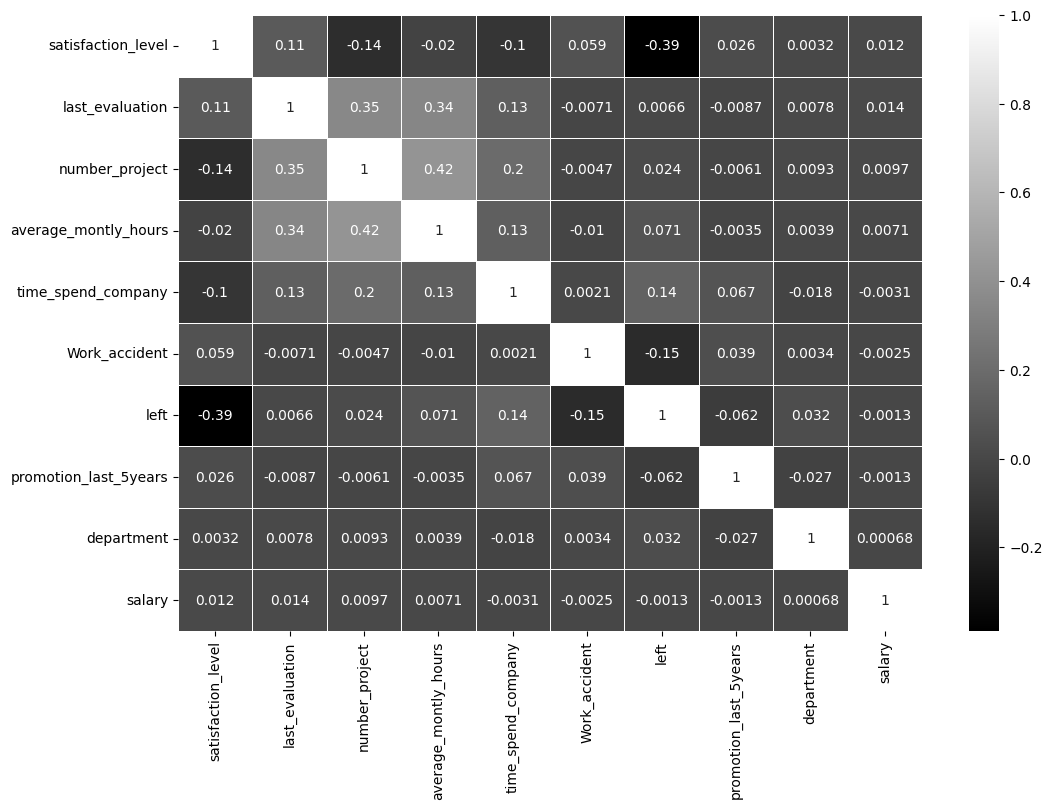

In [60]:
#correlation of data
corr = df.corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='grey', linewidths=0.5)
plt.show()

In [61]:
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,department,salary
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268,5.870525,1.347290
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281,2.868786,0.625819
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000,4.000000,1.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000,7.000000,1.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000,8.000000,2.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000,9.000000,2.000000


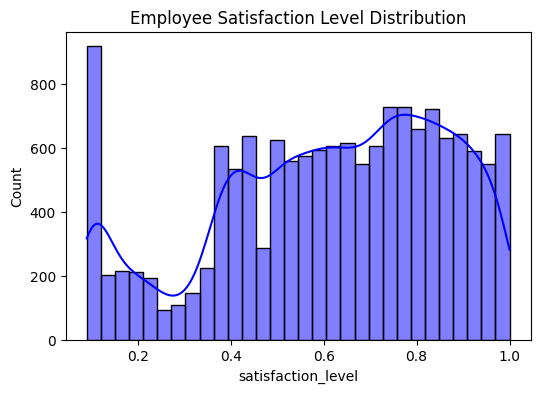

In [62]:
plt.figure(figsize=(6, 4))
sns.histplot(df['satisfaction_level'], kde=True, color='blue')
plt.title('Employee Satisfaction Level Distribution')
plt.show()

### Observations:
**Bimodal Distribution:** The distribution of satisfaction levels appears to have two prominent peaks, suggesting a bimodal distribution. This indicates that employees tend to cluster around two distinct levels of satisfaction:

    - One peak near low satisfaction (around 0.1 to 0.2).
    - Another broader peak near high satisfaction (around 0.7 to 1.0).

**High Count at Low Satisfaction:** There is a large spike in the number of employees with very low satisfaction (close to 0.1). This could signify a segment of employees who are highly dissatisfied with their jobs.

**Even Distribution at Moderate Levels:** In the middle range (between 0.3 and 0.6), the satisfaction levels are distributed fairly evenly, but without any significant peaks. This suggests that fewer employees fall in the "moderate satisfaction" range.

**Peak at High Satisfaction:** The second noticeable peak occurs between 0.7 and 1.0, indicating a significant proportion of employees are highly satisfied with their job.

**Dip Around 0.2 - 0.3:** There's a sharp decline between 0.2 and 0.3, suggesting that relatively few employees have slightly low satisfaction levels. This could reflect a polarization where employees are either very satisfied or highly dissatisfied.

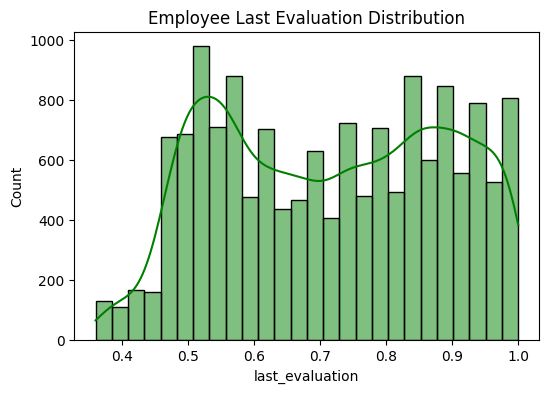

In [63]:
plt.figure(figsize=(6, 4))
sns.histplot(df['last_evaluation'], kde=True, color='green')
plt.title('Employee Last Evaluation Distribution')
plt.show()

### Observation
**Bimodal Distribution:** Similar to the satisfaction level distribution, the last evaluation scores exhibit a bimodal distribution with two noticeable peaks:

    - One peak between 0.5 and 0.6.
    - Another peak near 0.8 and 1.0.
    
**High Count at Mid Evaluation (0.5 - 0.6):** There is a strong peak around 0.5 to 0.6, indicating that many employees received average to slightly above-average evaluations.

**Another Peak at High Evaluation (0.8 - 1.0):** There’s also a significant group of employees who received very high evaluations, with many scoring above 0.8. This suggests that a large portion of employees is performing at a high level, according to their evaluations.

**Fewer Employees with Low Evaluation (< 0.5):** Comparatively, there are fewer employees with low evaluation scores (below 0.5), suggesting that poor performance is less common within the company.

**Dip Around 0.6 - 0.7:** There is a noticeable drop in the number of employees evaluated between 0.6 and 0.7. This might indicate a threshold where evaluations either group employees into "high" or "average/low" performers without many falling into the middle.

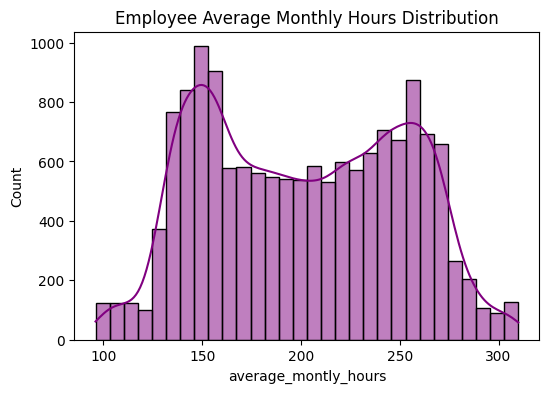

In [64]:
plt.figure(figsize=(6, 4))
sns.histplot(df['average_montly_hours'], kde=True, color='purple')
plt.title('Employee Average Monthly Hours Distribution')
plt.show()

### Observations:
**Bimodal Distribution:** The graph displays two distinct peaks, indicating a bimodal distribution of the average monthly hours worked by employees:

    - One peak around 150 hours.
    - Another peak around 250 hours.

**First Peak (~150 hours):** A large group of employees works around 150 hours per month, which is approximately equivalent to 37.5 hours per week. This group likely represents employees working within a standard or low-workload environment.

**Second Peak (~250 hours):** Another significant group of employees works close to 250 hours per month, or about 62.5 hours per week. This could indicate a high-workload environment where employees are working significantly more than standard hours.

**Lower Counts Between Peaks (~200 hours):** The middle range, between 200 and 220 hours, has fewer employees, suggesting a clear divide between those working a regular amount of hours and those who are working substantial overtime.

**Higher Monthly Hours (> 250 hours):** There is a small but notable portion of employees working more than 250 hours per month, even reaching up to 300 hours. This indicates a very high workload that might lead to employee burnout if sustained for long periods.

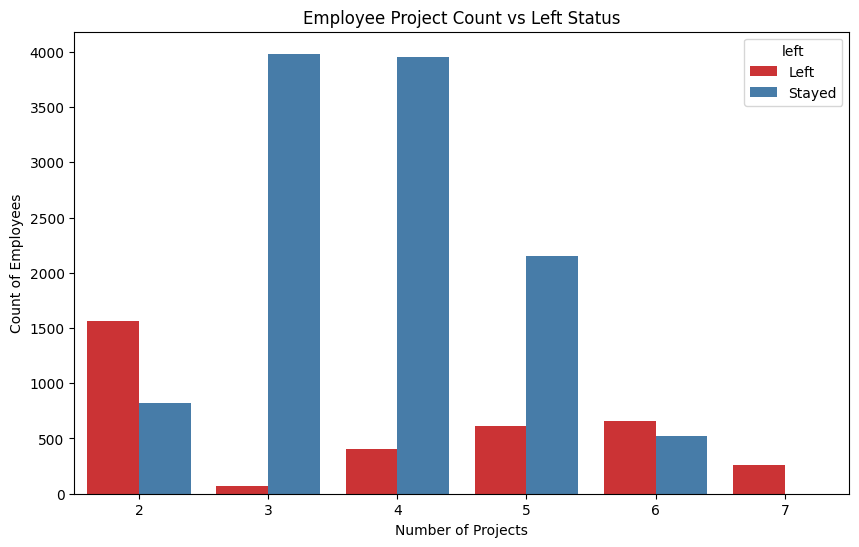

In [65]:
# Copy the dataframe
df_left_mode = df.copy()

# Convert 'left' column to categorical labels
df_left_mode['left'] = np.where(df_left_mode['left'] == 1, 'Left', 'Stayed')

# Plot the barplot
plt.figure(figsize=(10, 6))

# Bar plot showing the number of projects for employees who left or stayed
sns.countplot(x='number_project', hue='left', data=df_left_mode, palette='Set1')

# Add labels and title
plt.title('Employee Project Count vs Left Status')
plt.xlabel('Number of Projects')
plt.ylabel('Count of Employees')

# Display the plot
plt.show()

### Observation

**Low Projects (2 or fewer):**

    - Employees with 2 projects or fewer show a higher tendency to leave compared to those with 3 or more projects.
    - This may indicate that employees involved in fewer projects feel underutilized or less engaged, which could lead to dissatisfaction and eventual turnover.

**Mid-range Projects (3-4 projects):**

    - The majority of employees with 3 or 4 projects stayed with the company. Very few employees in this range left.
    - This suggests that employees managing 3-4 projects might have an optimal workload, balancing engagement without feeling overwhelmed.

**High Project Count (6-7 projects):**

    - Employees with 6 or 7 projects tend to leave more frequently compared to those with 5 projects.
    - A higher workload (6-7 projects) might be causing burnout, leading to a higher turnover rate among these employees.

## Supervised Attrition Modeling — Leakage-Safe Industry Flow

**Standard flow:**

1. Keep the **20% stratified test set completely untouched**.
2. Run **5-fold stratified cross-validation only on the 80% training set**.
3. Inside every CV fold, apply **SMOTENC only to that fold's training subset**; the validation fold stays untouched.
4. Compare **mean ROC-AUC across the 5 validation folds** for Random Forest and Gradient Boosting.
5. Select the model with the higher mean CV ROC-AUC.
6. Fit the selected pipeline once on **all 80% training data**; resampling still happens inside the pipeline.
7. Evaluate the final model **once on the untouched 20% test set**.
8. Use the final model's predicted attrition scores to create four business-facing risk zones.

In [66]:
# Separate features and target from the ORIGINAL (unencoded) dataframe.
# Keeping categorical columns intact lets SMOTENC handle mixed numeric/categorical data correctly.

target_col = 'left'
categorical_cols = ['department', 'salary']
numeric_cols = [
    'satisfaction_level',
    'last_evaluation',
    'number_project',
    'average_montly_hours',
    'time_spend_company',
    'Work_accident',
    'promotion_last_5years'
]

feature_cols = numeric_cols + categorical_cols
X = df_raw[feature_cols].copy()
y = df_raw[target_col].copy()

print('Feature shape:', X.shape)
print('Class distribution:\n', y.value_counts(normalize=True).sort_index())


Feature shape: (14999, 9)
Class distribution:
 left
0    0.761917
1    0.238083
Name: proportion, dtype: float64


In [67]:
# Hold out the final test set BEFORE any resampling or model fitting.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=123
)

print('Training rows:', len(X_train))
print('Test rows:', len(X_test))
print('\nTraining class distribution:')
print(y_train.value_counts(normalize=True).sort_index())
print('\nTest class distribution:')
print(y_test.value_counts(normalize=True).sort_index())


Training rows: 11999
Test rows: 3000

Training class distribution:
left
0    0.761897
1    0.238103
Name: proportion, dtype: float64

Test class distribution:
left
0    0.762
1    0.238
Name: proportion, dtype: float64


### Why SMOTENC belongs inside the CV pipeline

The dataset contains both numerical and categorical features. `SMOTENC` is the SMOTE variant designed for mixed-type data. Putting it **inside the cross-validation pipeline** guarantees that synthetic samples are generated only from the training portion of each fold, so validation and final test rows never influence resampling.

In [68]:
# Preprocess AFTER SMOTENC inside the CV pipeline.
# Numeric features are passed through; categorical features are one-hot encoded.
preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', 'passthrough', numeric_cols),
        ('categorical', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

# X is ordered as numeric columns followed by categorical columns.
categorical_indices = [len(numeric_cols), len(numeric_cols) + 1]

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

### Candidate-model design

**Logistic Regression** is included as an interpretable baseline. The ensemble models are then compared against that baseline using the same leakage-safe 5-fold ROC-AUC protocol. This makes the model-selection story more complete than comparing only two tree ensembles.

In [50]:
# Candidate models: a simple baseline + two nonlinear ensemble models.
# Numeric features are standardized so the Logistic Regression baseline is well-conditioned;
# tree-based models are unaffected materially by the scaling.
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=2000,
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        learning_rate=0.05,
        n_estimators=300,
        max_depth=9,
        min_samples_split=10,
        min_samples_leaf=2,
        subsample=0.9,
        random_state=42
    )
}

def build_pipeline(model):
    return Pipeline([
        ('smotenc', SMOTENC(
            categorical_features=categorical_indices,
            random_state=42
        )),
        ('preprocessor', ColumnTransformer(
            transformers=[
                ('numeric', StandardScaler(), numeric_cols),
                ('categorical', OneHotEncoder(
                    handle_unknown='ignore',
                    sparse_output=False
                ), categorical_cols)
            ]
        )),
        ('model', model)
    ])


In [69]:
# 5-fold CV:
# - Each fold gets its own training/validation split.
# - SMOTENC is fitted ONLY on that fold's training subset.
# - The validation fold remains untouched.
# - ROC-AUC is the model-selection metric.
cv_results = []
pipelines = {}
fold_auc_results = {}

for model_name, model in models.items():
    pipeline = build_pipeline(model)
    pipelines[model_name] = pipeline

    fold_auc = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1
    )

    fold_auc_results[model_name] = fold_auc

    cv_results.append({
        'Model': model_name,
        'Fold 1 ROC-AUC': fold_auc[0],
        'Fold 2 ROC-AUC': fold_auc[1],
        'Fold 3 ROC-AUC': fold_auc[2],
        'Fold 4 ROC-AUC': fold_auc[3],
        'Fold 5 ROC-AUC': fold_auc[4],
        'Mean ROC-AUC': fold_auc.mean(),
        'Std ROC-AUC': fold_auc.std()
    })

cv_results_df = (
    pd.DataFrame(cv_results)
    .sort_values('Mean ROC-AUC', ascending=False)
    .reset_index(drop=True)
)

cv_results_df


,Model,Fold 1 ROC-AUC,Fold 2 ROC-AUC,Fold 3 ROC-AUC,Fold 4 ROC-AUC,Fold 5 ROC-AUC,Mean ROC-AUC,Std ROC-AUC
0,Gradient Boosting,0.991332,0.988730,0.993474,0.995137,0.989404,0.991615,0.002415
1,Random Forest,0.989940,0.984146,0.992253,0.995729,0.986039,0.989622,0.004175
2,Logistic Regression,0.840862,0.813596,0.812811,0.838837,0.818006,0.824822,0.012413


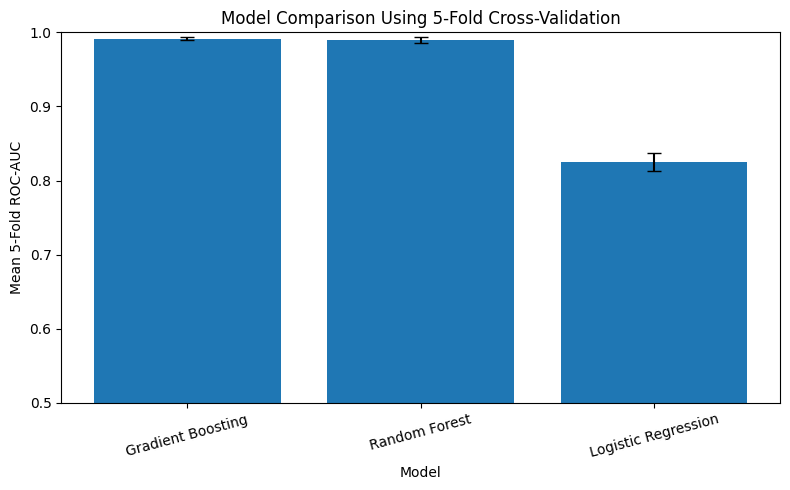

In [70]:
## Cross-validation model comparison
# This plot uses ONLY validation-fold ROC-AUC values from the 80% training set.
# It does not use the 20% held-out test set.

plot_df = cv_results_df.copy()

plt.figure(figsize=(8, 5))
plt.bar(
    plot_df['Model'],
    plot_df['Mean ROC-AUC'],
    yerr=plot_df['Std ROC-AUC'],
    capsize=5
)
plt.ylim(0.5, 1.0)
plt.ylabel('Mean 5-Fold ROC-AUC')
plt.xlabel('Model')
plt.title('Model Comparison Using 5-Fold Cross-Validation')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


### Model selection

The **three candidate classifiers** are compared using mean 5-fold validation ROC-AUC:

1. **Logistic Regression** — interpretable linear baseline.
2. **Random Forest** — bagged tree ensemble capturing nonlinear interactions.
3. **Gradient Boosting** — sequential boosting ensemble for nonlinear prediction.

The model with the **highest mean 5-fold validation ROC-AUC** is selected. The 20% test set is not used for model selection.

In [71]:
# Select the model using ONLY mean cross-validation ROC-AUC.
best_model_name = cv_results_df.loc[0, 'Model']
best_pipeline = pipelines[best_model_name]

print('Selected model:', best_model_name)
print('Mean CV ROC-AUC:', round(cv_results_df.loc[0, 'Mean ROC-AUC'], 4))

Selected model: Gradient Boosting
Mean CV ROC-AUC: 0.9916


## Final Training and One-Time Test Evaluation

After CV model selection, **only the selected model** is fitted on the complete 80% training set. The 20% test set is used **once** for final unbiased evaluation.

The test set must not be used for choosing between Logistic Regression, Random Forest, and Gradient Boosting.

In [72]:
# Final fit on the complete 80% training set.
best_pipeline.fit(X_train, y_train)

# ONE-TIME evaluation on the untouched 20% test set.
y_test_pred = best_pipeline.predict(X_test)
y_test_prob = best_pipeline.predict_proba(X_test)[:, 1]

final_accuracy = accuracy_score(y_test, y_test_pred)
final_auc = roc_auc_score(y_test, y_test_prob)

print(f'Final model: {best_model_name}')
print(f'Test Accuracy: {final_accuracy:.4f}')
print(f'Test ROC-AUC: {final_auc:.4f}')
print('\nClassification Report:\n')
print(classification_report(y_test, y_test_pred))


Final model: Gradient Boosting
Test Accuracy: 0.9890
Test ROC-AUC: 0.9950

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2286
           1       0.97      0.98      0.98       714

    accuracy                           0.99      3000
   macro avg       0.98      0.99      0.98      3000
weighted avg       0.99      0.99      0.99      3000



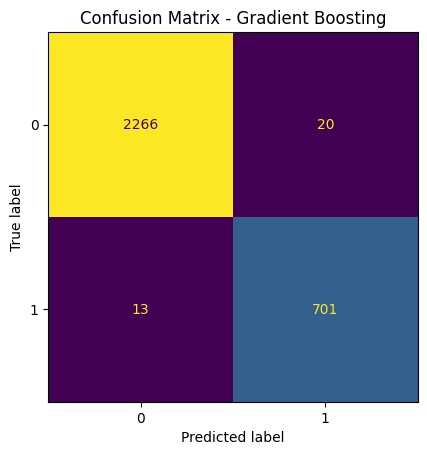

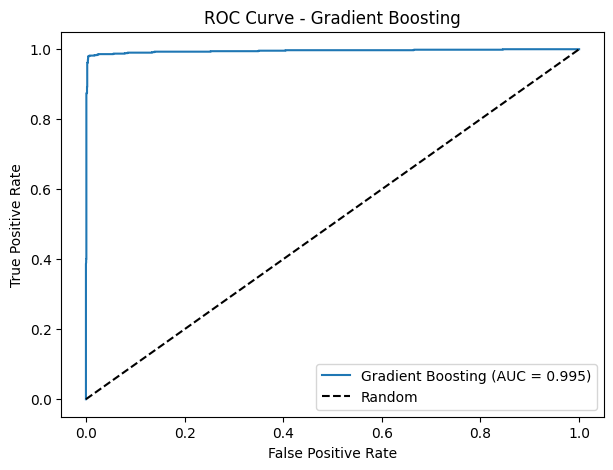

In [73]:
# Confusion matrix on the untouched test set.
cm = confusion_matrix(y_test, y_test_pred)
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=best_pipeline.named_steps['model'].classes_
).plot(colorbar=False)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()

# ROC curve on the untouched test set for the selected final model ONLY.
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'{best_model_name} (AUC = {final_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve - {best_model_name}')
plt.legend(loc='lower right')
plt.show()

## Employee Risk Scoring

Risk zones are **business-defined thresholds over the final model's predicted attrition score**. They are separate from K-Means: the classifier produces individual risk scores; K-Means produces behavioral segments.

In [74]:
# Score every employee using the final selected model.
all_risk_prob = best_pipeline.predict_proba(X)[:, 1]

scored_employees = df_raw.copy()
scored_employees['attrition_risk_probability'] = all_risk_prob
scored_employees['risk_zone'] = pd.cut(
    scored_employees['attrition_risk_probability'],
    bins=[-np.inf, 0.20, 0.60, 0.90, np.inf],
    labels=['Safe Zone (<20%)', 'Low Risk (20-60%)', 'Medium Risk (60-90%)', 'High Risk (>90%)']
)

risk_summary = (
    scored_employees.groupby('risk_zone', observed=False)
    .agg(
        employees=('risk_zone', 'size'),
        avg_risk_probability=('attrition_risk_probability', 'mean')
    )
    .reset_index()
)

risk_summary

,risk_zone,employees,avg_risk_probability
0,Safe Zone (<20%),11394,0.004987
1,Low Risk (20-60%),31,0.320879
2,Medium Risk (60-90%),65,0.822323
3,High Risk (>90%),3509,0.997135


## K-Means Employee Segmentation

K-Means is used as a **separate unsupervised segmentation layer**. The target `left` is **not** used to create clusters. We standardize behavioral features, select an interpretable cluster count using silhouette score, fit K-Means, and then use attrition rate only for **post-clustering business interpretation**.

In [47]:
cluster_features = [
    'satisfaction_level',
    'last_evaluation',
    'number_project',
    'average_montly_hours',
    'time_spend_company'
]

X_cluster = df_raw[cluster_features].copy()
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

# Select K from a small, interpretable range using silhouette score.
silhouette_scores = {}
for k in range(2, 6):
    candidate = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = candidate.fit_predict(X_cluster_scaled)
    silhouette_scores[k] = silhouette_score(X_cluster_scaled, labels)

silhouette_df = pd.DataFrame({
    'n_clusters': list(silhouette_scores.keys()),
    'silhouette_score': list(silhouette_scores.values())
})

best_k = int(silhouette_df.loc[silhouette_df['silhouette_score'].idxmax(), 'n_clusters'])
print('Selected K:', best_k)
silhouette_df

Selected K: 4


,n_clusters,silhouette_score
0,2,0.246143
1,3,0.243329
2,4,0.278471
3,5,0.260259


In [48]:
# Fit final K-Means with the selected K.
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
df_clustered = df_raw.copy()
df_clustered['cluster'] = kmeans.fit_predict(X_cluster_scaled)

# Attrition rate is used ONLY after clustering to understand each segment.
cluster_profile = (
    df_clustered.groupby('cluster')
    .agg(
        employees=('left', 'size'),
        attrition_rate=('left', 'mean'),
        avg_satisfaction=('satisfaction_level', 'mean'),
        avg_evaluation=('last_evaluation', 'mean'),
        avg_projects=('number_project', 'mean'),
        avg_monthly_hours=('average_montly_hours', 'mean'),
        avg_tenure=('time_spend_company', 'mean')
    )
    .sort_values('attrition_rate', ascending=False)
)

cluster_profile

,employees,attrition_rate,avg_satisfaction,avg_evaluation,avg_projects,avg_monthly_hours,avg_tenure
cluster,,,,,,,
2,1783,0.541784,0.173186,0.807257,5.644420,247.983174,4.254066
1,1928,0.469917,0.752993,0.822225,4.202801,222.184129,6.178423
0,3835,0.411995,0.479296,0.546245,2.722555,153.136115,3.143155
3,7453,0.015967,0.750467,0.754243,3.815108,209.010063,2.806789


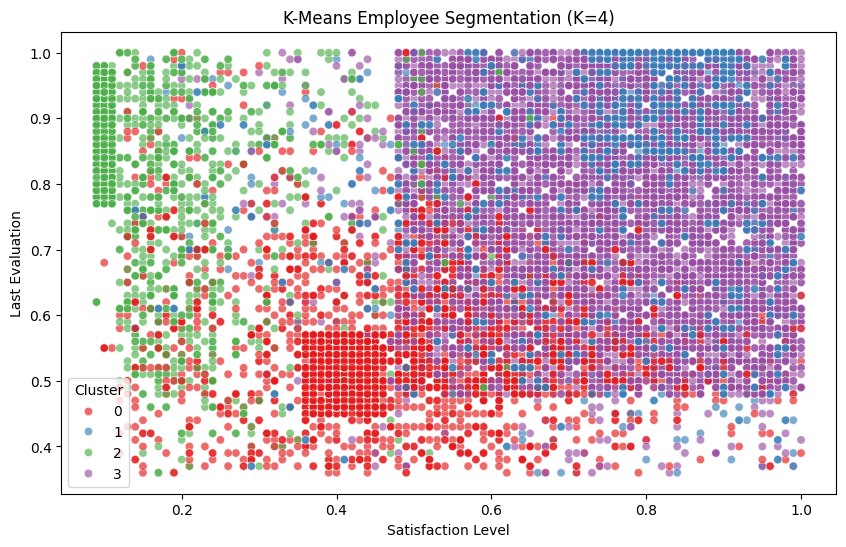

In [49]:
# Visualize the employee segments on two high-signal behavioral dimensions.
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='satisfaction_level',
    y='last_evaluation',
    hue='cluster',
    data=df_clustered,
    palette='Set1',
    alpha=0.65
)
plt.title(f'K-Means Employee Segmentation (K={best_k})')
plt.xlabel('Satisfaction Level')
plt.ylabel('Last Evaluation')
plt.legend(title='Cluster')
plt.show()

## Final Project Takeaway

The project now cleanly separates:

- **Supervised prediction:** Logistic Regression, Random Forest, and Gradient Boosting are compared using mean 5-fold validation ROC-AUC on the 80% training set.
- **Leakage-safe resampling:** SMOTENC is fitted independently inside each CV training fold; validation and final test samples remain untouched.
- **Model selection:** The candidate with the highest mean CV ROC-AUC is selected without using the 20% test set.
- **Final evaluation:** The selected model is retrained on all 80% training data and evaluated once on the untouched 20% test set.
- **Risk scoring:** The selected model's predicted attrition probabilities are mapped to four business-defined risk zones.
- **Unsupervised segmentation:** K-Means creates behavioral employee segments without using the `left` target; attrition rate is used only after clustering for business interpretation.